# Improving Recommendation By Improving the Quality of Image Embeddings with SigLIP and Vertex AI

In part two "**02 - ResNet and Elasticsearch**", we saw that convolutional neural networks (CNNs) have semantic limitations: *CNNs-based embeddings capture low and mid-level features such as edge, texture, and color, but they do not explicitly encode global and semantic information like Vision Language Models do.*

As illustrated in [this medium story](https://pub.towardsai.net/building-an-image-based-recommendation-system-and-search-engine-with-deep-learning-and-4bb96c4d9a64), recommendations perfomed with CNNs based embeddings can includ semantically incorrect items. I had to apply additional filtering step, using **Filtered $k$NN** with Elasticsearch to improve recommendation quality. 

Another way to improve recommendation quality is by using Vision Language Models to extract image embeddings: Compared to CNNs, VLMs are designed to capture semantic informations.

In this notebook, we are going to explore how to improve recommendation quality by using VLMs based models to extract embeddings: **SigLIP** and the **Vertex AI Multimodal Embedding API**.

**Prerequisities**

Before running this notebook, please ensure you have the followings:

* A running Elasticsearch instance (eg. ```http://localhost:9200```)
* The Elasticsearch instance has an ```items``` index with the mapping defined in part two of this repository.

To follow along, please run the first then cells of this [notebook](./../02%20-%20ResNet%20and%20Elasticsearch/src/IBRS%20and%20Search%20Engine.ipynb) from part two. This will ensure you have you Elasticsearch instance up and running with the appropriate indexed documents

In [31]:
from elasticsearch import Elasticsearch
from src.settings import DATASET_DIR, MODEL_FIELD_MAPPING
from src.utils import unzip_dataset
import os

es = Elasticsearch("http://localhost:9200")

# unzip dataset if not yet done
unzip_dataset()

## 1. Embedding Extraction with SigLIP

Defining an abstract base class for embedding extraction, and concrete implementations for SigLIP and latter on for Vertex AI.

In [1]:
from abc import ABC, abstractmethod
from typing import List
import numpy as np
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModel


class ImageEmbeddingExtractor(ABC):
    @abstractmethod
    def extract_embeddings(self, image_paths: List[str]) -> np.ndarray:
        """Extract embeddings for a batch of image paths."""
        pass


class SigLIPEmbeddingExtractor(ImageEmbeddingExtractor):
    def __init__(self, model_name="google/siglip-base-patch16-224"):
        self.processor = AutoProcessor.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model.eval()

    def extract_embeddings(self, image_paths: List[str]) -> np.ndarray:
        images = [Image.open(path).convert("RGB") for path in image_paths]
        inputs = self.processor(images=images, return_tensors="pt")
        with torch.no_grad():
            embeddings = self.model.get_image_features(**inputs)
            embeddings = embeddings.pooler_output
        return embeddings.detach().cpu().numpy()

/home/projects/IBRS/Image-Based-Recommendation-System/03 - Image Embeddings with VLM based models/etc/venv-03/lib/python3.12/site-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


Similariy, the ResNet50 Embedding Extractor can be defined as follows:

```python
class ResNet50EmbeddingExtractor(ImageEmbeddingExtractor):
    def __init__():
        base_model = resnet50.ResNet50(weights='imagenet')
        model = Model(inputs=base_model.inputs, outputs=base_model.get_layer('avg_pool').output)

    def extract_embeddings(self, image_paths: List[str]):
        images = [load_image(path) for path in image_paths]
        batch = np.stack(images, axis=0)
        return self.model.predict(batch, verbose=0)
```

### Test Embedding Extraction with SigLIP

In [3]:
# create an instance of the SigLIP Embedding Extractor
siglip_extractor = SigLIPEmbeddingExtractor()

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

In [13]:
# set test image, you can use any image paths
test_paths = ["/home/projects/IBRS/Image-Based-Recommendation-System/etc/dataset/img1.jpg"]

# extract embeddings of the test image and display its shape
embeddings = siglip_extractor.extract_embeddings(test_paths)
np.shape(embeddings)

## 2. Extract All Embeddings and Update ES

Before extracting embeddings, we need to update the elasticsearch's index mapping and add a new attribute that will be used to story the SigLIP vector.

1. Update Index Mapping
2. Extract Embeddings and Store in ES

### 2.1. Update the Elasticsearch Index Mapping

The existing index, the ***items*** from Elasticsearch as the following mapping:
```json
mapping = {
  "mappings": {
    "properties": {
      "ID": {
        "type": "integer"
      },
      "title": {
        "type": "text",
        "fields": {
          "keyword": {
            "type": "keyword"
          }
        }
      },
      "slug": {
        "type": "text",
        "fields": {
          "keyword": {
            "type": "keyword"
          }
        }
      },
      "category": {
        "type": "keyword"
      },
      "imPath": {
        "type": "keyword"
      },
      "image_features": {
        "type": "dense_vector",
        "dims": 2048,
        "index": True,
        "similarity": "cosine"
      }
    }
  }
}
```

In order to store new embeddings vectors, the SigLIP embeddings vectors in this case, we need to update the ```items``` index. We will add a ```image_features_siglip``` attribute as follows:

In [19]:
from src.elastic import update_index_mapping

siglip_field = MODEL_FIELD_MAPPING.get("siglip")

# define the new attribute for the siglip embedding vector
new_mapping_properties = {
    "properties": {
        siglip_field: { 
            "type": "dense_vector",
            "dims": 768,
            "index": True,
            "similarity": "cosine"
        }
    }
}

update_index_mapping(es, index_name="items", body=new_mapping_properties)

In [7]:
# check that the mapping has been updated
es.indices.get_mapping(index="items")

ObjectApiResponse({'items': {'mappings': {'properties': {'ID': {'type': 'integer'}, 'category': {'type': 'keyword'}, 'imPath': {'type': 'keyword'}, 'image_features': {'type': 'dense_vector', 'dims': 2048, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'image_features_siglip': {'type': 'dense_vector', 'dims': 768, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'siglip_features': {'type': 'dense_vector', 'dims': 768, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'slug': {'type': 'text', 'fields': {'keyword': {'type': 'keyword'}}}, 'title': {'type': 'text', 'fields': {'keyword': {'type': 'keyword'}}}}}}})

### 2.2. Extract and Store All Embeddings

In [29]:
from src.elastic import bulk_update_embeddings

def extract_embeddings_and_update_es(es, embedding_extractor: ImageEmbeddingExtractor, model: str = "resnet", index_name: str = "items", batch_size=128):
    # query ES to get all the image path
    query = {
        "size": batch_size,
        "query": {
            "bool": {
                "must_not": {
                    "exists": {"field": MODEL_FIELD_MAPPING.get(model)}
                }
            }
        }
    }
    
    response = es.search(index=index_name, body=query, scroll="5m")
    scroll_id = response["_scroll_id"]
    
    while True:
        items = response["hits"]["hits"]
    
        if not items:
            break
    
        # batch processing
        paths = [os.path.join(DATASET_DIR, item["_source"]["imPath"]) for item in items]
        embeddings = embedding_extractor.extract_embeddings(paths)
        bulk_update_embeddings(es, index_name, items, embeddings, model)
    
        # continue scrolling
        response = es.scroll(scroll_id=scroll_id, scroll="5m")
    
    print("DONE: all embeddings updated.")

In [32]:
# extract the SigLIP image embeddings and update the Elasticsearch index
extract_embeddings_and_update_es(
    es=es, 
    embedding_extractor=siglip_extractor, 
    model="siglip"
)

[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 119 documents with siglip embeddings.
DONE: all embeddings updated.


## 3. Perform Recommendations

This section not only shows the resulting recommandation, but allow emphasize the recommendation quality when using SigLIP compared to ResNet.

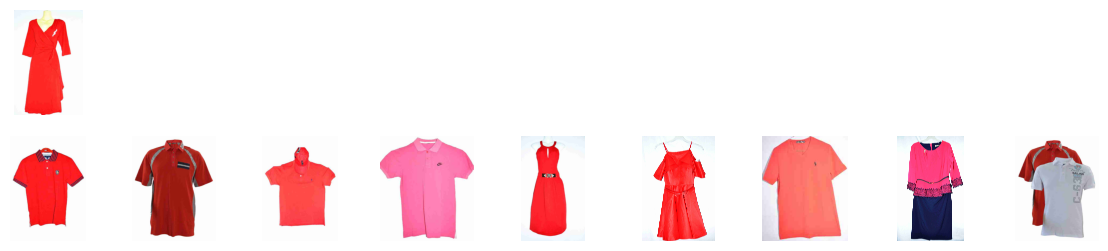

In [2]:
from src.utils import make_recommendations

# recommendation with resnet embeddings
make_recommendations(es=es, item_id=1087, model="resnet")

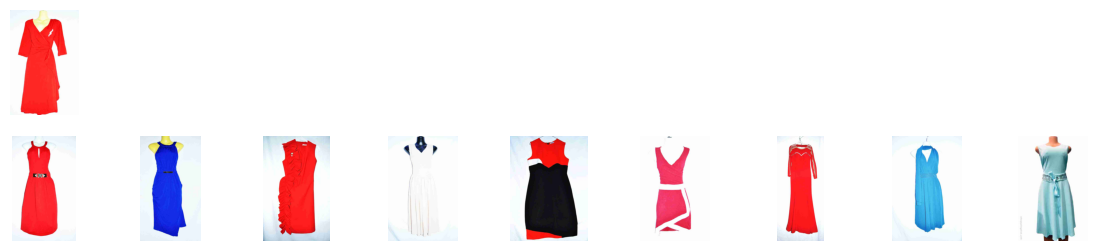

In [3]:
# recommendation with siglip embeddings
make_recommendations(es=es, item_id=1087, model="siglip")

## Embedding Extraction with Vertex AI

In [ ]:
from vertexai.vision_models import MultiModalEmbeddingModel, Image as VertexImage

class VertexAIEmbeddingExtractor(ImageEmbeddingExtractor):
    def __init__(self, model_name="multimodalembedding"):
        self.model = MultiModalEmbeddingModel.from_pretrained(model_name)

    def extract_embeddings(self, image_paths: List[str]) -> np.ndarray:
        embeddings = []
        for path in image_paths:
            vertex_image = VertexImage.load_from_file(path)
            emb = self.model.get_embeddings(image=vertex_image)
            embeddings.append(emb.image_embedding)
        return np.array(embeddings)

# Building an Image-based Search Engine

In [21]:
img_paths = [
    os.path.join(DATASET_DIR, 'img1.jpg'), # woman shoes
    os.path.join(DATASET_DIR, 'img2.png')  # woman afritude
]

img_vectors = extract_embeddings_batch(paths=img_paths)

In [22]:
def image_based_search(src_vector, k=10, num_candidates=100):

    # build the knn query.
    knn_query = {
        "knn": {
            "field": "image_features",
            "query_vector": src_vector,
            "k": k,
            "num_candidates": num_candidates
        }
    }
        
    # execute the knn query
    res = es.search(index=index_name, query=knn_query)
    knn_results = res['hits']['hits']
    return knn_results

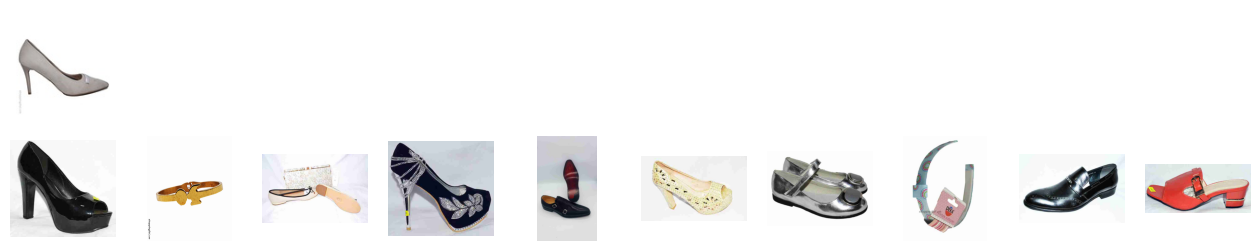

In [23]:
knn_results = image_based_search(img_vectors[0])
display_knn(knn_items=knn_results, src_img_path=img_paths[0])

Second example

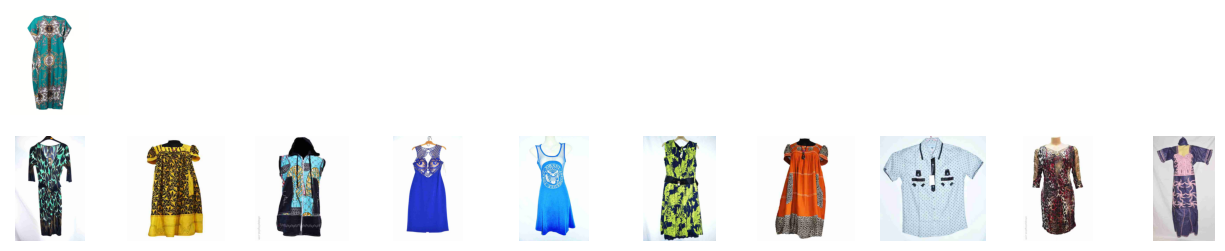

In [24]:
knn2_results = image_based_search(img_vectors[1])
display_knn(knn_items=knn2_results, src_img_path=img_paths[1])

The result is not the great, but as described in [this medium post](https://medium.com/towards-artificial-intelligence/building-an-image-based-recommendation-system-and-search-engine-with-deep-learning-and-4bb96c4d9a64), there is room for improvements.

One way to mitigate this issue is by applying a classification model to determine the category of the item in the image, then applying a filtered knn search using the predicted category.

### Author
Carmel WENGA, Data & ML Engineer
- [Medium](https://medium.com/@carmelwenga)
- [LinkedIn](https://www.linkedin.com/in/carmel-christian-wenga-871876178/)